# AMM（自動マーケットメーカー）

## DEXとオーダーブックの問題

**DEX（Decentralized Exchange, 分散型取引所）** は、スマートコントラクトでトークンの交換を行う取引所。中央集権型取引所（CEX）では、取引は企業のサーバー上で行われ、ブロックチェーンには入出金だけが記録される。DEXでは取引そのものがチェーン上で行われる。

初期のDEX（EtherDelta, 0xなど）は、CEXと同じ **オーダーブック（板）方式** を模倣していた。しかし、

- 注文の発注・取消のたびにgasがかかり、ブロック時間だけ遅れる
- その結果マーケットメーカーが集まらず、板が薄い（流動性が低い）
- 相手がいないと取引が成立しない

という問題があり、普及しなかった。これを解決したのが **AMM（Automated Market Maker）** で、2018年のUniswap V1、2020年のV2で一気に普及した。

## AMMの仕組み

AMMでは、取引相手の代わりに **流動性プール（liquidity pool）** と取引する。

- プールには2種類のトークンX, Yが預けられている
- 交換比率（価格）は、プール内のトークン残高から数式で自動的に決まる
- プールにトークンを預ける人を **流動性提供者（LP, Liquidity Provider）** と呼び、取引手数料を受け取る

プレイヤーは「交換したい人」と「LP」の2種類だけで、どちらも誰かに強制されているわけではなく、インセンティブだけで動いている。

### 定積公式（CPAMM）

Uniswap V2は **定積マーケットメーカー（Constant Product Market Maker, CPAMM）** を採用している。プール内のX, Yの残高を $x, y$ として、交換の前後で積が一定に保たれるように交換量を決める。

$$
x \cdot y = (x + \Delta x)(y - \Delta y) = k
$$

ここから、Xを $\Delta x$ 入れたときに受け取れるYの量は

$$
\Delta y = y - \frac{k}{x + \Delta x} = \frac{y \Delta x}{x + \Delta x}
$$

となる。Uniswap V2では0.3%の手数料がかかり、入れたXのうち99.7%（$\gamma = 0.997$）だけが交換に使われる。

$$
\Delta y = \frac{y \gamma \Delta x}{x + \gamma \Delta x}
$$

手数料分はプールに残るので、取引のたびに $k$ が少しずつ増え、LPの取り分が増えていく。

In [1]:
def swap(x: float, y: float, dx: float, fee: float = 0.003) -> tuple[float, float, float]:
    """Xをdx入れてYを受け取る。(受け取ったY, 新しいx, 新しいy) を返す"""
    dx_eff = dx * (1 - fee)
    dy = y * dx_eff / (x + dx_eff)
    return dy, x + dx, y - dy


x, y = 20.0, 50.0
print(f"初期: x={x}, y={y}, k={x * y:.1f}, Xの価格={y / x:.3f} Y")
dy, x2, y2 = swap(x, y, 10)
print(f"Xを10入れる → Yを{dy:.2f}受け取る（平均価格 {dy / 10:.3f} Y/X）")
print(f"交換後: x={x2}, y={y2:.2f}, k={x2 * y2:.1f}, Xの価格={y2 / x2:.3f} Y")

初期: x=20.0, y=50.0, k=1000.0, Xの価格=2.500 Y
Xを10入れる → Yを16.63受け取る（平均価格 1.663 Y/X）
交換後: x=30.0, y=33.37, k=1001.0, Xの価格=1.112 Y


### 価格とスリッページ

プール内の価格（限界的な交換比率）は

$$
p = \frac{y}{x} \quad (\text{1 X あたりの Y の量})
$$

で、取引するたびに変わる。上の例では、交換前は1 X = 2.5 Yだったのに、10 X入れたときの平均の交換比率は1 X ≒ 1.66 Yになっている。プールの規模に対して取引量が大きいほど、不利な価格で約定する（**価格インパクト**, price impact）。

$xy = k$ のグラフは双曲線なので、どれだけXを入れてもYが枯渇することはない。Yが少なくなるほど、Yを得るのに必要なXが急激に増えていく。これにより、相手がいなくても常に取引できる。

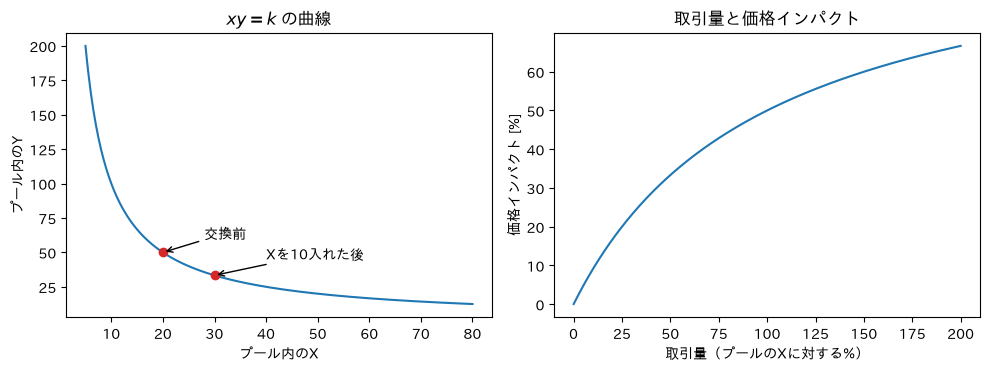

In [2]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import numpy as np

k = 20 * 50
xs = np.linspace(5, 80, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(xs, k / xs)
axes[0].scatter([20, 30], [50, k / 30], color="C3", zorder=3)
axes[0].annotate("交換前", (20, 50), xytext=(28, 60), arrowprops=dict(arrowstyle="->"))
axes[0].annotate("Xを10入れた後", (30, k / 30), xytext=(40, 45), arrowprops=dict(arrowstyle="->"))
axes[0].set(xlabel="プール内のX", ylabel="プール内のY", title="$xy=k$ の曲線")

trade = np.linspace(0.01, 40, 300)
received = 50 * trade / (20 + trade)
axes[1].plot(trade / 20 * 100, (1 - (received / trade) / 2.5) * 100)
axes[1].set(xlabel="取引量（プールのXに対する%）", ylabel="価格インパクト [%]", title="取引量と価格インパクト")
plt.tight_layout()
plt.show()

## 流動性の提供

### LPトークン

LPは、その時点の価格に沿った比率でXとYの両方をプールに預け、持ち分を表す **LPトークン**（ERC-20）を受け取る。

- 預け入れ：プールの残高が $a$ 倍に増えるように預けると、LPトークンの総発行量も $a$ 倍になるように新規発行される

$$
\Delta L = \min\left(\frac{\Delta x}{x}, \frac{\Delta y}{y}\right) L
$$

- 引き出し：LPトークンを返却（バーン）すると、総発行量に占める割合に応じてX, Yを受け取れる
- プールの最初の作成時には $\sqrt{x_0 y_0}$ だけLPトークンが発行される（Uniswap V2では、そこから少量（MINIMUM_LIQUIDITY）を永久にロックして、極端に少ない流動性による操作を防いでいる）

取引手数料はプールに積み上がるので、1 LPトークンあたりのX, Yの量は時間とともに増えていく。

### 裁定取引による価格の調整

AMMは外部の価格を知らない。それでもAMMの価格が市場価格に追随するのは、**裁定取引（アービトラージ）** があるからである。

- AMMの価格がCEXなど他の市場より安ければ、AMMで買って他で売れば儲かる
- その取引によってAMMの価格は上がり、市場価格に近づく

LPのインセンティブも同様に働く。取引量の割にプールが小さければ手数料の利回りが高いのでLPが集まり、逆ならLPは他のプールへ移る。結果として、プールの規模は取引量に見合った水準に落ち着く。

## インパーマネントロス

LPは、価格が変動すると「プールに預けずにそのまま持っていた場合（HODL）」と比べて損をする。これを **インパーマネントロス（impermanent loss, 変動損失）** と呼ぶ。

裁定取引者は、市場価格に合わせてAMMから値上がりしたトークンを買い取っていく。その結果、LPの手元には値上がりしたトークンが減り、値下がりしたトークンが増える。

預け入れ時の価格を $p_0$、現在の価格を $p_1 = r p_0$ とすると、CPAMMでは

$$
\frac{\text{LPポジションの価値}}{\text{HODLの価値}} = \frac{2\sqrt{r}}{1 + r}
$$

となる。

:::{admonition} 導出
定積公式のもとで価格が $p = y/x$ のとき、残高は $x = \sqrt{k/p},\ y = \sqrt{kp}$。Y建てのLPポジションの価値は $V_{LP} = px + y = 2\sqrt{kp_1}$。

一方、最初の残高 $x_0 = \sqrt{k/p_0},\ y_0 = \sqrt{kp_0}$ をそのまま持っていた場合の価値は $V_{HODL} = p_1 x_0 + y_0 = \sqrt{k}\,(p_1 / \sqrt{p_0} + \sqrt{p_0})$。

比を取ると $V_{LP}/V_{HODL} = 2\sqrt{r} / (1 + r)$。
:::

価格が元に戻れば損失も消える（だから「インパーマネント」）が、価格が戻らないまま引き出せば損失は確定する。LPが利益を出せるのは、手数料収入がこの損失を上回る場合に限られる。

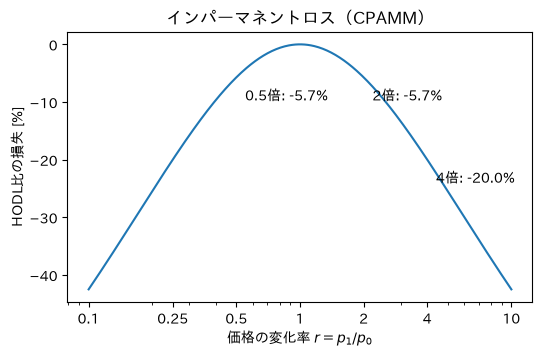

In [3]:
r = np.logspace(-1, 1, 400)
il = 2 * np.sqrt(r) / (1 + r) - 1

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(r, il * 100)
ax.set(xscale="log", xlabel="価格の変化率 $r = p_1 / p_0$", ylabel="HODL比の損失 [%]", title="インパーマネントロス（CPAMM）")
for ratio in [0.5, 2, 4]:
    v = (2 * np.sqrt(ratio) / (1 + ratio) - 1) * 100
    ax.annotate(f"{ratio}倍: {v:.1f}%", (ratio, v), xytext=(ratio * 1.1, v - 4))
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 10], ["0.1", "0.25", "0.5", "1", "2", "4", "10"])
plt.show()

価格が2倍（または半分）になると約5.7%、4倍で20%の損失になる。

近年は、インパーマネントロスの代わりに **LVR（Loss-Versus-Rebalancing）** という指標で、LPが裁定取引者に支払っている損失をより正確に測る研究も進んでいる（Milionis et al., 2022）。

## AMMの発展

### Uniswap V3：集中流動性

V2では、流動性が価格0〜∞の全範囲に均等に分散しているため、実際に取引が起きる価格帯の流動性は資本のごく一部にすぎない。

V3（2021年）では、LPが流動性を提供する価格帯 $[p_a, p_b]$ を指定できる **集中流動性（concentrated liquidity）** を導入した。

- 同じ資本でも、狭い価格帯に集中させれば、その価格帯ではV2より何倍も深い流動性を提供できる（資本効率の向上）
- 価格が範囲外に出ると、ポジションは片方のトークンだけになり、手数料を得られなくなる
- LPのポジションはそれぞれ価格帯が異なるため、ERC-20ではなくNFT（ERC-721）で表される

LPは価格帯を能動的に管理する必要があり、プロのマーケットメーカーに近い運用になった。

### Uniswap V4：Hooks

V4（2025年）では、すべてのプールを1つのコントラクトで管理するシングルトン設計にしてgasを削減し、**Hooks** と呼ばれる外部コントラクトで、プールの作成・スワップ・流動性の追加などの前後に任意の処理を差し込めるようにした（動的な手数料、指値注文、TWAMMなど）。

### その他の不変式

| 方式 | 不変式・仕組み | 用途 | 例 |
| --- | --- | --- | --- |
| 定積（CPAMM） | $xy = k$ | 一般的なトークンペア | Uniswap V2 |
| 定和（CSMM） | $x + y = k$ | 価格インパクトがないが、片方が枯渇しうる | — |
| StableSwap | 定和と定積の中間 | 同じ価値を持つべき資産同士（USDC/USDT, ETH/stETH） | Curve |
| 加重定積 | $\prod_i x_i^{w_i} = k$ | 3種類以上のトークン、任意の比率のポートフォリオ | Balancer |
| LMSR | 対数コスト関数 | 予測市場 | （→[予測市場](../prediction_markets.ipynb)） |

### DEXアグリゲーターとインテント

価格は複数のDEXやプールに分散しているため、それらを横断して最良の経路を探す **DEXアグリゲーター**（1inch, 0x, ParaSwapなど）が使われる。さらに、ユーザーは「Xを売ってYを最低これだけ欲しい」という条件（インテント）に署名するだけで、ソルバーが競争して最良の約定方法を探す方式（CoW Swap, UniswapX）も広がっている。これはMEV対策にもなる（→[MEV](./mev.ipynb)）。

## 参考文献

- Adams, H. et al. (2020). [Uniswap v2 Core](https://app.uniswap.org/whitepaper.pdf).
- Adams, H. et al. (2021). [Uniswap v3 Core](https://app.uniswap.org/whitepaper-v3.pdf).
- Egorov, M. (2019). [StableSwap - efficient mechanism for Stablecoin liquidity](https://curve.fi/files/stableswap-paper.pdf).
- Angeris, G. & Chitra, T. (2020). [Improved Price Oracles: Constant Function Market Makers](https://arxiv.org/abs/2003.10001).
- Milionis, J. et al. (2022). [Automated Market Making and Loss-Versus-Rebalancing](https://arxiv.org/abs/2208.06046).